AVALIAÇÃO DE CARROS POR MEIO DE SUAS CARACTERÍSTICAS

In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
carE_df = pd.read_csv("carEvaluation.csv")
carE_df.head()

,buying,maint,doors,persons,lug_boot,safety,values
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [22]:
carE_df.describe()

,buying,maint,doors,persons,lug_boot,safety,values
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [23]:
carE_df.info()
carE_df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   values    1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
values      0
dtype: int64

Como pode-se perceber, nos dados do meu dataset escolhido não há dados faltosos, que poderiam influenciar nas minhas contas, sendo assim, a necessidade de uma limpeza prévia. Com o intuito de por em pratica a Atividade 1, modifiquei alguns itens da minha lista para implementar um método de limpeza (Apenas para teste, o utilizado no decorrer do trabalho é o original).

In [5]:
carE_teste_df = pd.read_csv("carEvaluation_limpeza.csv")
carE_teste_df.info()
carE_teste_df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1714 non-null   str  
 1   maint     1714 non-null   str  
 2   doors     1720 non-null   str  
 3   persons   1720 non-null   str  
 4   lug_boot  1714 non-null   str  
 5   safety    1713 non-null   str  
 6   values    1721 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


buying      14
maint       14
doors        8
persons      8
lug_boot    14
safety      15
values       7
dtype: int64

Apaguei alguns valores, e usei o isnull() para identificar e o sum() para somar esse valores que eu removi, agora implementarei o método hot-deck que consiste em preencher com valor aleatorio de mesmo atributo de um objeto similar. Vou mostrar os 10 primeiros já que eu tirei alguns dados dele, e depois vou mostar por quais dados foram atribuidos.

In [6]:
carE_teste_df.head(10)

,buying,maint,doors,persons,lug_boot,safety,values
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,NaN,NaN,unacc
6,vhigh,vhigh,2,2,NaN,NaN,unacc
7,vhigh,vhigh,2,2,NaN,NaN,unacc
8,vhigh,vhigh,2,2,NaN,NaN,unacc
9,vhigh,vhigh,2,4,NaN,NaN,unacc


In [7]:
for col in carE_teste_df.columns:
    missing = carE_teste_df[col].isnull()
    carE_teste_df.loc[missing, col] = np.random.choice(carE_teste_df[col].dropna(), size=missing.sum())

In [8]:
carE_teste_df.head(10)

,buying,maint,doors,persons,lug_boot,safety,values
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,high,unacc
8,vhigh,vhigh,2,2,med,low,unacc
9,vhigh,vhigh,2,4,small,low,unacc


In [9]:
carE_teste_df.info()
carE_teste_df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   values    1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
values      0
dtype: int64

Com o teste agora temos nenhuma variável faltando, ou seja, todos os valores preenchidos.

Implementando os exercícios da Atividade 2: já que meu dataset é composto por dados categoricos, agora passarei para numérico para realizar a padronização e depois o PCA (já voltando com a tabela original).

In [32]:
encoders = {}
carE_numerico_df = carE_df.copy()

for col in carE_numerico_df.columns:
    le = LabelEncoder()
    carE_numerico_df[col] = le.fit_transform(carE_numerico_df[col])
    encoders[col] = le

print(carE_numerico_df.head())
print(encoders['buying'].classes_)
print(encoders['maint'].classes_)
print(encoders['doors'].classes_)
print(encoders['persons'].classes_)
print(encoders['lug_boot'].classes_)
print(encoders['safety'].classes_)
print(encoders['values'].classes_)

   buying  maint  doors  persons  lug_boot  safety  values
0       3      3      0        0         2       1       2
1       3      3      0        0         2       2       2
2       3      3      0        0         2       0       2
3       3      3      0        0         1       1       2
4       3      3      0        0         1       2       2
['high' 'low' 'med' 'vhigh']
['high' 'low' 'med' 'vhigh']
['2' '3' '4' '5more']
['2' '4' 'more']
['big' 'med' 'small']
['high' 'low' 'med']
['acc' 'good' 'unacc' 'vgood']


Todos os dados foram passados para uma forma numérica utilizando o LabelEncoder, basicamente como se passasse e forma de opção, já que os valores dos atributos eram separados de tal forma:
   buying       v-high, high, med, low
   maint        v-high, high, med, low
   doors        2, 3, 4, 5-more
   persons      2, 4, more
   lug_boot     small, med, big
   safety       low, med, high

   class:
   values       unacc, acc, good, vgood

Já que meus dados são categóricos não faria muito sentido a implementação de padronização, já que a variação e a distancia dos dados não indicariam números reais, mas sim representativos. Mas para o exercício realizarei a implementação por meio do z-score e depois o PCA.

In [11]:
scaler = StandardScaler()
carE_PCA_df = carE_numerico_df.drop('values', axis=1)

y = carE_df['values']

X_scaled = scaler.fit_transform(carE_PCA_df)

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.16666667, 0.16666667])

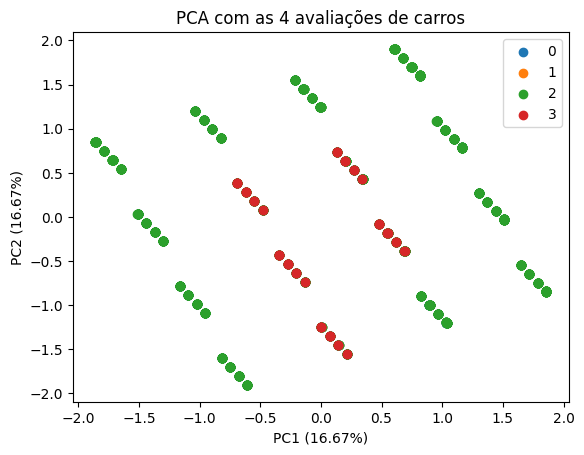

In [44]:
plt.figure()

classes = np.unique(y)

for classe in classes:
    plt.scatter(
        X_pca[y == classe, 0],
        X_pca[y == classe, 1],
        label=classe
        
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('PCA com as 4 avaliações de carros')
plt.legend()
plt.show()

In [14]:
corr = carE_PCA_df.corr()
corr

,buying,maint,doors,persons,lug_boot,safety
buying,1.000000e+00,-3.436808e-16,-2.097088e-16,-4.089152e-17,-1.691262e-16,-2.439415e-16
maint,-3.436808e-16,1.000000e+00,-6.466021e-17,-4.272143e-17,-1.549092e-16,-1.404810e-16
doors,-2.097088e-16,-6.466021e-17,1.000000e+00,1.956599e-17,-1.942523e-17,1.062757e-16
persons,-4.089152e-17,-4.272143e-17,1.956599e-17,1.000000e+00,3.854941e-18,3.392348e-17
lug_boot,-1.691262e-16,-1.549092e-16,-1.942523e-17,3.854941e-18,1.000000e+00,-1.541976e-17
safety,-2.439415e-16,-1.404810e-16,1.062757e-16,3.392348e-17,-1.541976e-17,1.000000e+00


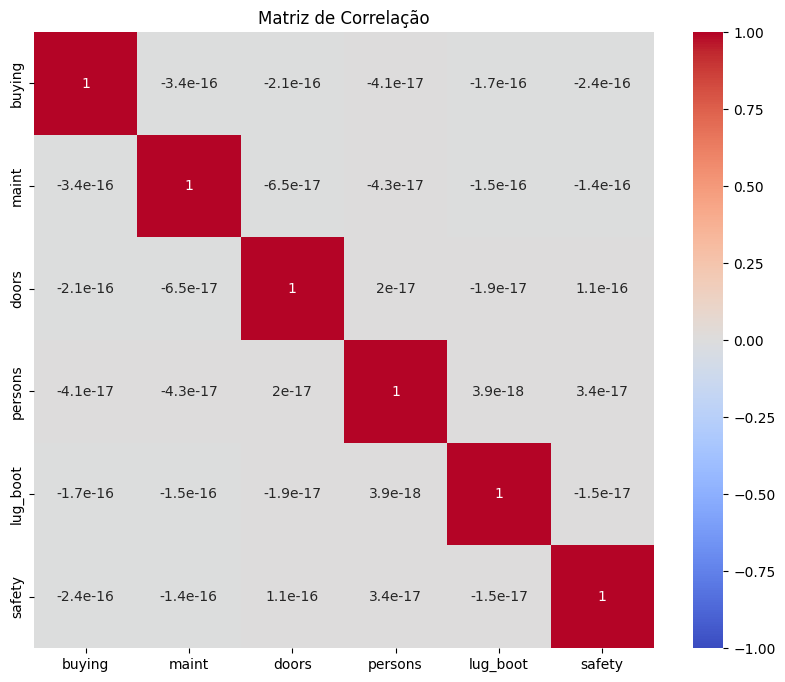

In [26]:
corr = carE_PCA_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,   
    vmax=1,    
    center=0
)

plt.title('Matriz de Correlação')
plt.show()

Atividade 3: agora aplicarei conceitos de estatística para os meus dados, primeiramente realizando a distribuiçãod e frequência de cada coluna que possuo.

In [39]:
carE_dados_df = carE_df.drop('values', axis = 1)
for col in carE_dados_df.columns:
    print(f'\n===== {col} =====')
    
    freq = carE_dados_df[col].value_counts()
    rel = carE_dados_df[col].value_counts(normalize=True)
    
    tabela = pd.DataFrame({
        'Frequência': freq,
        'Frequência (%)': rel * 100
    })
    
    print(tabela)


===== buying =====
        Frequência  Frequência (%)
buying                            
vhigh          432            25.0
high           432            25.0
med            432            25.0
low            432            25.0

===== maint =====
       Frequência  Frequência (%)
maint                            
vhigh         432            25.0
high          432            25.0
med           432            25.0
low           432            25.0

===== doors =====
       Frequência  Frequência (%)
doors                            
2             432            25.0
3             432            25.0
4             432            25.0
5more         432            25.0

===== persons =====
         Frequência  Frequência (%)
persons                            
2               576       33.333333
4               576       33.333333
more            576       33.333333

===== lug_boot =====
          Frequência  Frequência (%)
lug_boot                            
small            576       

Vou fazer um grafico de barras, através dos meus dados percebe-se que as classificações tiveram quantidades diferentes, então os graficos vão ficar com barras de mesmo tamanho ja que são igualmente distribuídos.

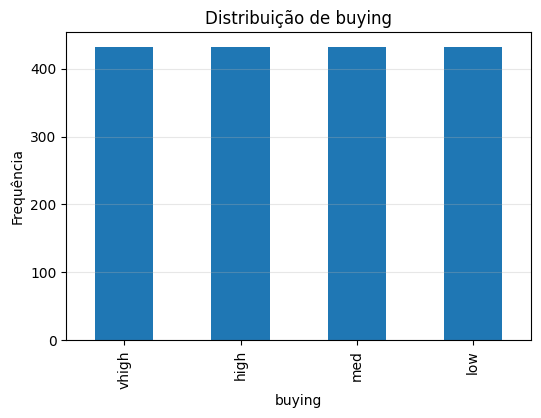

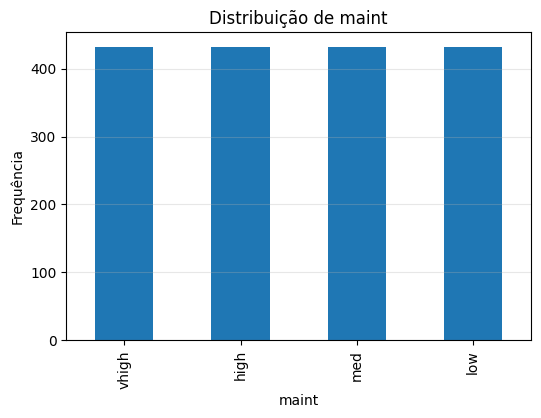

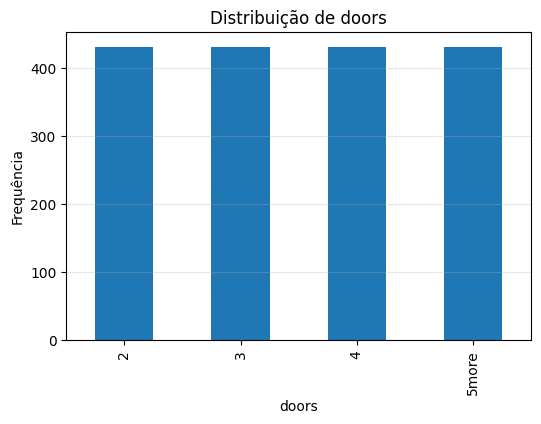

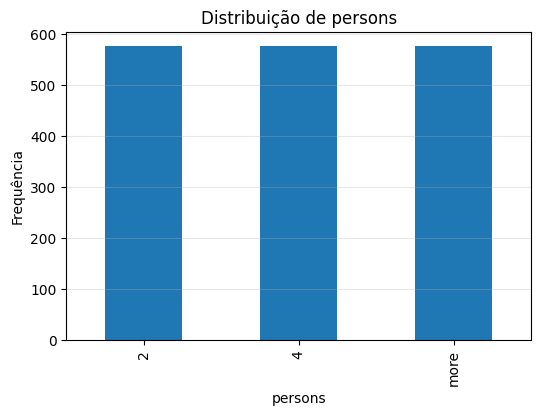

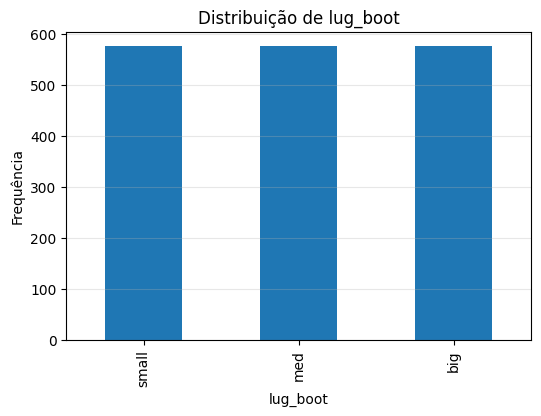

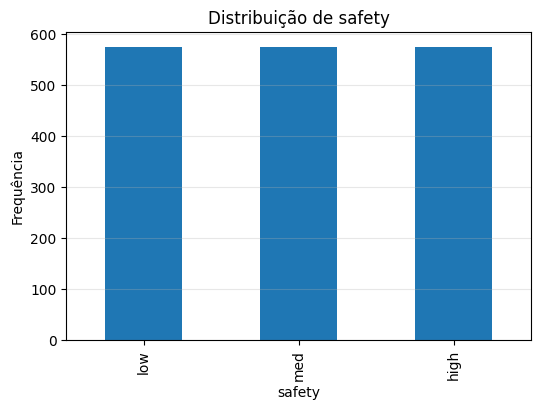

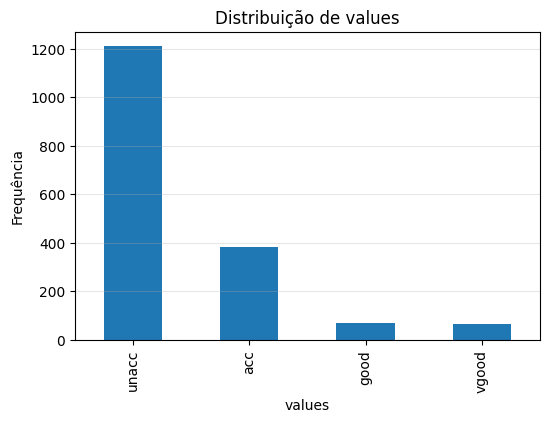

In [38]:
for col in carE_df.columns:
    plt.figure(figsize=(6,4))
    
    carE_df[col].value_counts().plot(kind='bar')
    
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
    plt.grid(axis='y', alpha=0.3)
    
    plt.show()

In [40]:
carE_df.head(15)

,buying,maint,doors,persons,lug_boot,safety,values
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,med,unacc
8,vhigh,vhigh,2,2,big,high,unacc
9,vhigh,vhigh,2,4,small,low,unacc


O criador da tabela utilizou todas as classificações possiveis para a contrução oq me fez perceber ser uma tabela montada, por mais que ele tenha pego valores externos com base de colunas que ele já havia estabelecido. Tirei essa conclusão por meio da tabela de frequência

In [45]:
carE_df.describe()

,buying,maint,doors,persons,lug_boot,safety,values
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [46]:
carE_numerico_df.describe()

,buying,maint,doors,persons,lug_boot,safety,values
count,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000
mean,1.500000,1.500000,1.500000,1.000000,1.000000,1.000000,1.553241
std,1.118358,1.118358,1.118358,0.816733,0.816733,0.816733,0.875948
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.750000,0.750000,0.750000,0.000000,0.000000,0.000000,1.000000
50%,1.500000,1.500000,1.500000,1.000000,1.000000,1.000000,2.000000
75%,2.250000,2.250000,2.250000,2.000000,2.000000,2.000000,2.000000
max,3.000000,3.000000,3.000000,2.000000,2.000000,2.000000,3.000000


In [48]:
carE_numerico_df.var(numeric_only=True)

buying      1.250724
maint       1.250724
doors       1.250724
persons     0.667053
lug_boot    0.667053
safety      0.667053
values      0.767285
dtype: float64

Foram utilizadas medidas de tendência central, dispersão, posição relativa e associação para análise estatística dos dados. Devido à natureza categórica do conjunto, destacam-se principalmente a moda, a distribuição de frequência e as relações entre variáveis.